**Завдання звучить так:**

Проаналізуй перформанс медіа сорсів та запропонуй варіанти покращення
закупівлі, використовуючи будь-який інструмент, який вважаєш зручним та підходящим.

Результат оформлюй як таблиці та візуалізації з текстовими поясненнями.

Відповідь має містити пропозиції щодо зупинки або запуску закупівлі з певною геотаргетацією для кожного з сорсів.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Курс Дата аналітик /Data/ТЗ /KissMyApps/Data Analyst Test Task Data new Yana - Task 3.csv', parse_dates=['install_date'],decimal=',' )

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1764 entries, 0 to 1763
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   install_date          1764 non-null   datetime64[ns]
 1   country_code          1757 non-null   object        
 2   media_source          1764 non-null   object        
 3   spend_usd             1764 non-null   float64       
 4   subscribers           1764 non-null   int64         
 5   erevenue_12month_usd  1764 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 82.8+ KB


,install_date,country_code,media_source,spend_usd,subscribers,erevenue_12month_usd
0,2020-12-28,AD,ms_1,0.070004,0,0.00000
1,2020-12-28,AE,ms_1,33.681845,1,27.99300
2,2020-12-28,AE,ms_2,10.449999,1,6.74706
3,2020-12-28,AF,ms_1,1.460100,0,0.00000
4,2020-12-28,AG,ms_1,0.190010,0,0.00000


In [4]:
df['romi'] = (df['erevenue_12month_usd'] - df['spend_usd']) / df['spend_usd']
df['cps'] = df['spend_usd'] / df['subscribers']
df['revenue_per_subscriber'] = df['erevenue_12month_usd'] / df['subscribers']

In [5]:
grouped = df.groupby(['media_source', 'country_code']).agg({
    'spend_usd': 'sum',
    'subscribers': 'sum',
    'erevenue_12month_usd': 'sum'
}).reset_index()

# Додаю метрики
grouped = grouped[grouped['subscribers'] > 0]  # фільтр, щоб уникнути ділення на 0
grouped = grouped[grouped['spend_usd'] > 0]  # прибираю рядки з нульовими витратами
grouped['romi'] = (grouped['erevenue_12month_usd'] - grouped['spend_usd']) / grouped['spend_usd']
grouped['cps'] = grouped['spend_usd'] / grouped['subscribers']
grouped['revenue_per_subscriber'] = grouped['erevenue_12month_usd'] / grouped['subscribers']

display(grouped)

,media_source,country_code,spend_usd,subscribers,erevenue_12month_usd,romi,cps,revenue_per_subscriber
1,ms_1,AE,355.223417,21,288.233401,-0.188586,16.915401,13.725400
3,ms_1,AG,1.039974,1,10.493000,9.089675,1.039974,10.493000
4,ms_1,AL,7.499836,1,10.493000,0.399097,7.499836,10.493000
5,ms_1,AM,3.179908,1,0.000000,-1.000000,3.179908,0.000000
7,ms_1,AR,93.265800,13,156.456500,0.677533,7.174292,12.035115
...,...,...,...,...,...,...,...,...
267,ms_2,TR,1.298565,1,0.000000,-1.000000,1.298565,0.000000
268,ms_2,US,2790.099556,344,4569.554500,0.637775,8.110755,13.283589
271,ms_3,AU,139.300000,20,148.730137,0.067697,6.965000,7.436507
272,ms_3,CA,406.590000,35,69.866914,-0.828164,11.616857,1.996198


Тепер хочу побудувати вже рекомендаційну таблицю.

In [6]:
def get_recommendation(romi):
    if romi < 0:
        return '❌ Зупинити'
    elif romi < 0.5:
        return '🟡 Перевірити'
    else:
        return '✅ Масштабувати'

grouped['recommendation'] = grouped['romi'].apply(get_recommendation)

In [7]:
recommendation_table = grouped[['media_source', 'country_code', 'romi', 'cps', 'revenue_per_subscriber', 'recommendation']]

# Сортуємо, щоб найпроблемніші джерела були зверху
recommendation_table = recommendation_table.sort_values(by='romi').reset_index(drop=True)

display(recommendation_table)

,media_source,country_code,romi,cps,revenue_per_subscriber,recommendation
0,ms_1,GP,-1.289961,15.508999,-4.497000,❌ Зупинити
1,ms_1,FI,-1.278476,85.168567,-23.717395,❌ Зупинити
2,ms_1,AM,-1.000000,3.179908,0.000000,❌ Зупинити
3,ms_1,BO,-1.000000,7.486367,0.000000,❌ Зупинити
4,ms_1,CN,-1.000000,27.419586,0.000000,❌ Зупинити
...,...,...,...,...,...,...
141,ms_2,DK,21.774182,1.229155,27.993000,✅ Масштабувати
142,ms_1,LA,30.229910,1.679960,52.465000,✅ Масштабувати
143,ms_1,VC,33.992081,0.799981,27.993000,✅ Масштабувати
144,ms_2,MA,59.737197,0.921083,55.944000,✅ Масштабувати


In [8]:
recommendation_table.to_csv('recommendation_table.csv', index=False)

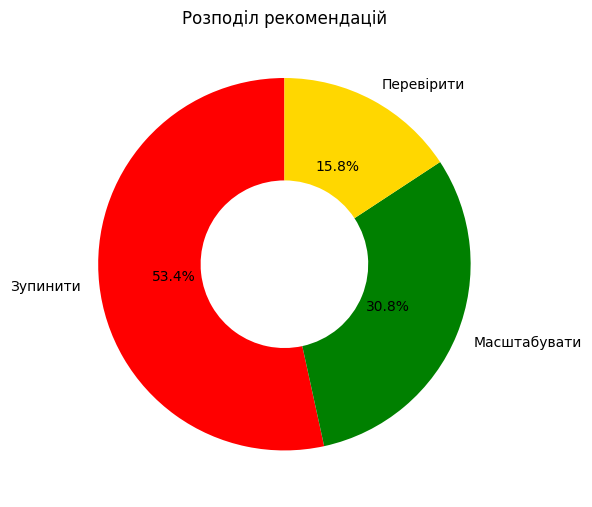

In [9]:
plt.figure(figsize=(6, 6))

# Заміню емодзі на текстові підписи, бо видавало попередження
recommendation_table['recommendation_clean'] = recommendation_table['recommendation'].replace({
    '❌ Зупинити': 'Зупинити',
    '🟡 Перевірити': 'Перевірити',
    '✅ Масштабувати': 'Масштабувати'
})

recommendation_table['recommendation_clean'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['red', 'green', 'gold'],
    wedgeprops=dict(width=0.55)
)

plt.title('Розподіл рекомендацій')
plt.ylabel('')
plt.tight_layout()
plt.show();

**Висновок:**

Більше половини закупок (53.4%) рекомендовано зупинити, оскільки вони не приносять очікуваного прибутку (ROMI < 0).  
Приблизно 31% джерел показали гарний результат — їх можна масштабувати.  
Ще 16% потребують додаткової перевірки.

Це дає підстави оптимізувати витрати, залишивши лише найефективніші кампанії.

Це був загальний аналіз на основі сукупного фактору ГЕО + джерела.
Але хочеться проаналізувати ще окремо які ж країни дають кращі результати, а які гірше.

А також окремо подивитись на ситуацію з джерелами.


In [10]:
geo_grouped = df.groupby('country_code').agg({
    'spend_usd': 'sum',
    'erevenue_12month_usd': 'sum',
    'subscribers': 'sum'
}).reset_index()

geo_grouped = geo_grouped[geo_grouped['subscribers'] > 0]
geo_grouped['romi'] = (geo_grouped['erevenue_12month_usd'] - geo_grouped['spend_usd']) / geo_grouped['spend_usd']
geo_grouped['cps'] = geo_grouped['spend_usd'] / geo_grouped['subscribers']
geo_grouped['revenue_per_subscriber'] = geo_grouped['erevenue_12month_usd'] / geo_grouped['subscribers']

display(geo_grouped.sort_values(by='romi'))

,country_code,spend_usd,erevenue_12month_usd,subscribers,romi,cps,revenue_per_subscriber
76,GP,15.508999,-4.497000,1,-1.289961,15.508999,-4.497000
59,FI,85.168567,-23.717395,4,-1.278476,21.292142,-5.929349
5,AM,3.179908,0.000000,1,-1.000000,3.179908,0.000000
25,BO,22.459101,0.000000,3,-1.000000,7.486367,0.000000
41,CN,27.419586,0.000000,1,-1.000000,27.419586,0.000000
...,...,...,...,...,...,...,...
210,UY,35.097180,445.536800,8,11.694376,4.387148,55.692100
193,TC,1.319971,27.993000,1,20.207284,1.319971,27.993000
109,LA,1.679960,52.465000,1,30.229910,1.679960,52.465000
212,VC,0.799981,27.993000,1,33.992081,0.799981,27.993000


Хочу зрозуміти предметний рейтинг країн по ROMI

In [11]:
# Додаю колонку з % прибутку або доходу
geo_grouped['romi_contribution_%'] = 100 * geo_grouped['romi'] / geo_grouped['romi'].sum()

geo_grouped_sorted = geo_grouped.sort_values(by='romi_contribution_%', ascending=False)

display(geo_grouped_sorted[['country_code', 'romi', 'romi_contribution_%']])

,country_code,romi,romi_contribution_%
21,BJ,62.621611,31.146731
212,VC,33.992081,16.906978
109,LA,30.229910,15.035750
193,TC,20.207284,10.050697
210,UY,11.694376,5.816548
...,...,...,...
180,SI,-1.000000,-0.497380
202,TR,-1.000000,-0.497380
213,VE,-1.000000,-0.497380
59,FI,-1.278476,-0.635888


In [12]:
geo_grouped_sorted.to_csv('geo_grouped_sorted_by_romi_contribution_percent.csv', index=False)

**Висновки з аналізу ROMI по країнах:**

1. **Найбільший внесок у ROMI формує країна BJ (31.1%)**

   * Високий ROMI — **62.6**
   * Ключова країна — має стратегічне значення
**Рекомендація**: обов'язково масштабувати закупку

2. **Наступні країни з високим ROMI:**

   * **VC (16.9%)**, **LA (15.0%)**, **TC (10.1%)**
   * Разом з BJ ці 4 країни формують **понад 73% усього прибутку**
   * Їх слід вважати основними драйверами доходу

3. **Країни з найгіршими показниками:**

   * Наприклад, **FI (-0.63%)**, **GP (-0.64%)**, **VE (-0.49%)**
   * ROMI від’ємний — **реклама в цих регіонах збиткова**
**Рекомендація**: зупинити або переглянути стратегію закупки


Тепер проаналізую окремо медіа джерела.

In [13]:
media_grouped = recommendation_table.groupby('media_source').agg({
    'romi': 'mean',
    'cps': 'mean',
    'revenue_per_subscriber': 'mean',
    'country_code': 'count'
}).rename(columns={'country_code': 'geo_count'}).reset_index()

media_grouped = media_grouped.sort_values(by='romi', ascending=False)
display(media_grouped)

,media_source,romi,cps,revenue_per_subscriber,geo_count
1,ms_2,3.969012,4.915024,10.317417,30
0,ms_1,1.709029,14.029002,14.020621,113
2,ms_3,0.099544,7.663160,6.169480,3


In [14]:
media_grouped.to_csv('media_grouped.csv', index=False)

**Висновки по ефективності `media_source`:**

1. **ms\_2 — найефективніше джерело**

* **ROMI = 3.97** — найвищий
* **Низький CPS (4.91$)** — ефективне залучення
* Хоч і охоплює **лише 30 гео**, але якість дуже висока

**Рекомендація**: масштабувати трафік із цього джерела

2. **ms\_1 — середній показник**

* **ROMI = 1.71** — прибуткове, але вдвічі гірше за ms\_2
* **CPS = 14.02\$** — найдорожче залучення
* **Найбільше охоплення: 113 гео**

**Рекомендація**: лишити варто, але перевірити окремі країни


3. **ms\_3 — слабке джерело**

* **ROMI = 0.10** — майже нульовий
* **Низький revenue per subscriber**
* **Кількість гео взагалі дуже мала**

**Рекомендація**: **перевірити або зупинити** це джерело